# TP3 - Solving MDPs (Planning)
## Gridworld: Policy Evaluation, Value Iteration y Policy Iteration

Author: Lucía Porlán Ferrando   
Subject: Introduction to reinforcement learning   

# 1. Theoretical Introduction

In this work, we study a sequantial decision-making problem modeled as a Markov Decicion process (MDP).

An MDP is defined by:
+ A set of states, $S$.
+ A set of actions, $A$.
+ Transition dynamics $P(s'|s,a)$.
+ A reward function.
+ Discount factor $\gamma$.

The objective is to evaluate policies and find the optimal policy that maximizes the cumulative expected reward.

In this assigment, we work with a Gridworld environment, where the agent moves within a grid. Some cells are terminal, one cell is inaccessible, and the actions are stochastic: even if the agent chooses a specific direction, there ir a small probability of moving in another.

Two main problems will be addressed:
1. **Performance Prediction:** Evaluating the performance of a given policy.
2. **Optimization:** Obtaining the optimal policy through dynamic programming algorithms.


# 2. Environment Description

The environment is a grid of 3 rows by 4 columns. It consists of:
+ Normal states with a reward of $-0.04$.
+ A terminal state with a reward of $+1$.
+ A terminal state with a reward of $-1$.
+ One inaccessible cell.

The possible actions are:
+ 0: Up
+ 1: Right
+ 2: Down
+ 3: Left

Transitions are stochastic. If the agent chooses an action, th desired direction is executed with a probability of $0.7$, while each of the other three directions occurs with a probability of $0.1$.

Furthermore, if a move hits a wall or the blocked cell, the agent remains in the same state.

The discount factor is $\gamma = 0.99$.

# 3. Environment Definition

## 3.1 Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 3.2 State Matrix

In [2]:
state_matrix = np.zeros((3, 4))
state_matrix[0, 3] = 1      
state_matrix[1, 3] = 1      
state_matrix[1, 1] = -1     

print("State Matrix:")
print(state_matrix)

State Matrix:
[[ 0.  0.  0.  1.]
 [ 0. -1.  0.  1.]
 [ 0.  0.  0.  0.]]


## 3.3 Reward Matrix

Reward Matrix:
[[-0.04 -0.04 -0.04  1.  ]
 [-0.04 -0.04 -0.04 -1.  ]
 [-0.04 -0.04 -0.04 -0.04]]


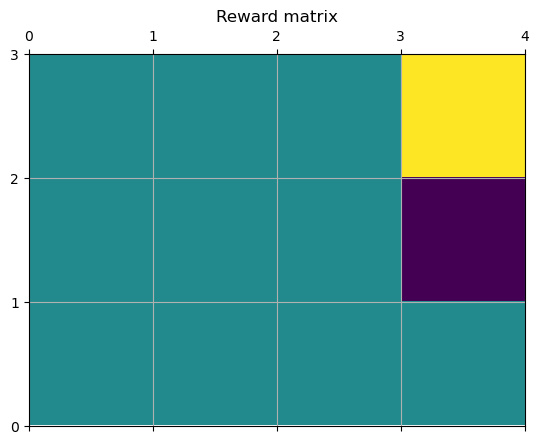

In [3]:
reward_matrix = np.full((3, 4), -0.04)
reward_matrix[0, 3] = 1.0
reward_matrix[1, 3] = -1.0

print("Reward Matrix:")
print(reward_matrix)

plt.matshow(reward_matrix, extent=[0, 4, 0, 3])
plt.title("Reward matrix")
plt.grid()
plt.show()

## 3.4 Given Policy

In [4]:
policy_matrix = np.array([
    [0,      3,  3, -1],
    [3, np.nan,  3, -1],
    [3,      2,  0,  3]
], dtype=float)

print(policy_matrix)

[[ 0.  3.  3. -1.]
 [ 3. nan  3. -1.]
 [ 3.  2.  0.  3.]]


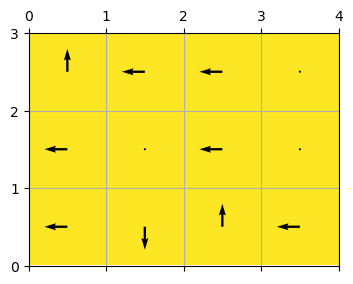

In [5]:
def print_policy(policy_matrix2, V=np.array([]), lstates=[]):
    policy_matrix = policy_matrix2[::-1]
    shape = policy_matrix.shape
    U = np.zeros(shape)
    R = np.zeros(shape)

    for row in range(shape[0]):
        for col in range(shape[1]):
            val = policy_matrix[row, col]

            if val == -1:
                U[row, col] = 0
                R[row, col] = 0
            elif val == 0:
                U[row, col] = 0
                R[row, col] = 1
            elif val == 1:
                U[row, col] = 1
                R[row, col] = 0
            elif val == 2:
                U[row, col] = 0
                R[row, col] = -1
            elif val == 3:
                U[row, col] = -1
                R[row, col] = 0
            elif np.isnan(val):
                U[row, col] = 0
                R[row, col] = 0

    plt.rcParams['figure.figsize'] = (4, 3)

    if V.size == 0:
        V = np.ones(shape)
        for x in lstates:
            V[x.multi_index] = 0.7
        plt.matshow(V, extent=[0, 4, 0, 3], vmin=0, vmax=1)
    else:
        plt.matshow(V, extent=[0, 4, 0, 3])

    plt.grid()
    X, Y = np.meshgrid(np.arange(0.5, 4.5, 1), np.arange(0.5, 3.5, 1))
    plt.quiver(X, Y, U, R)
    plt.show()

print_policy(policy_matrix)

## 3.5 Transition Matrix

In [6]:
transition_matrix = np.array([
    [0.7, 0.1, 0.1, 0.1],  
    [0.1, 0.7, 0.1, 0.1],  
    [0.1, 0.1, 0.7, 0.1],  
    [0.1, 0.1, 0.1, 0.7]   
])

gamma = 0.99

print("Transition matrix:")
print(transition_matrix)
print("Gamma:", gamma)

Transition matrix:
[[0.7 0.1 0.1 0.1]
 [0.1 0.7 0.1 0.1]
 [0.1 0.1 0.7 0.1]
 [0.1 0.1 0.1 0.7]]
Gamma: 0.99


## 3.6 Auxiliary Functions

In [ ]:
def prob_next_state(position, world_row=3, world_col=4):
    """
    Returns the list of possible next states, ordered as follows:
    [Up, Right, Down, Left]
    If the agent hits a wall or an impossible cell, it remains in the same state.
    """
    possible = []

    for action in range(4):
        position_def = position

        if action == 0:      # UP
            new_position = (position[0] - 1, position[1])
        elif action == 1:    # RIGHT
            new_position = (position[0], position[1] + 1)
        elif action == 2:    # DOWN
            new_position = (position[0] + 1, position[1])
        elif action == 3:    # LEFT
            new_position = (position[0], position[1] - 1)

        if 0 <= new_position[0] < world_row and 0 <= new_position[1] < world_col:
            if state_matrix[new_position] != -1:
                position_def = new_position

        possible.append(position_def)

    return possible

# 4. Performance Prediction

## 4.1 Theory Section

In this section, a given policy is evaluated.

The goal is not yet to find the best policy, but rather to calculate the value function $V^{\pi}(s)$, which represents the expected return when following policy $\pi$ from each state.

Two approaches will be used:
1. **Exact Algebraic Method**, by solving a linear system.
2. **Iterative Policy Evaluation**, by iteratively applying the Bellman operator associated with the policy.

Furthermore, it will be experimentally verified that the Bellman operator is a contraction, which guarantees the convergence of the iterative method.

In iterative policy evaluation, the goal is to calculte the value function $V^{\pi}$ associated with a fixed policy $\pi$.

The ipdate is performed using the Bellman expectation equation: $$V_{k+1}(s)=\sum_{s'} P(s'|s,\pi(s)) \left[ R(s') + \gamma V_k(s') \right]$$ The Bellman operator associated with a fixed policy is contractive; therefore, the iteration converges to a unique fixed point, which is precisely $V^\pi$.

## 4.2 Exercise 1

For a fixed policy $\pi$, the value function satisfies: $$V^{\pi} = R + \gamma P^{\pi} V^{\pi}$$

Equivalenty, $$(I - \gamma P^{\pi}) V^{\pi} = R$$

and therefore, $$V^{\pi} = (I - \gamma P^{\pi})^{-1} R$$

In this exercise, we will construct the transition matrix $P^{\pi}$ induced by the given policy and solve the associated linear system.

In [ ]:
def state_to_index(pos):
    return pos[0] * state_matrix.shape[1] + pos[1]

def get_P_pi(policy_matrix):
    n_states = state_matrix.shape[0] * state_matrix.shape[1]
    P = np.zeros((n_states, n_states))

    state = np.nditer(state_matrix, flags=['multi_index'])
    while not state.finished:
        s = state.multi_index
        idx = state_to_index(s)

        if state_matrix[s] == 0: 
            action = int(policy_matrix[s])
            next_states = prob_next_state(s)

            for ns, p in zip(next_states, transition_matrix[action]):
                P[idx, state_to_index(ns)] += p

        else:
            P[idx, :] = 0.0

        state.iternext()

    return P

def get_R_pi(policy_matrix):
    """
    Expected inmediate reward under the fixed policy.
    It must use the reward of the next state to be consistent with
    iterative_policy_evaluation.
    """
    n_states = state_matrix.shape[0] * state_matrix.shape[1]
    R_pi = np.zeros(n_states)

    state = np.nditer(state_matrix, flags=['multi_index'])
    while not state.finished:
        s = state.multi_index
        idx = state_to_index(s)

        if state_matrix[s] == 0:   
            action = int(policy_matrix[s])
            next_states = prob_next_state(s)

            expected_reward = 0.0
            for ns, p in zip(next_states, transition_matrix[action]):
                expected_reward += p * reward_matrix[ns]

            R_pi[idx] = expected_reward
        else:
            R_pi[idx] = 0.0

        state.iternext()

    return R_pi

P_pi = get_P_pi(policy_matrix)
R_pi = get_R_pi(policy_matrix)

I = np.eye(P_pi.shape[0])
V_vec = np.linalg.solve(I - gamma * P_pi, R_pi)

print("Value Vector:")
print(V_vec)

Value Vector:
[-2.88491762 -2.82657307 -2.29963326  0.         -2.83062759  0.
 -1.78943865  0.         -2.65821913 -2.35027724 -1.8756967  -1.7903464 ]


Exact Value function:
[[-2.88491762 -2.82657307 -2.29963326  0.        ]
 [-2.83062759  0.         -1.78943865  0.        ]
 [-2.65821913 -2.35027724 -1.8756967  -1.7903464 ]]


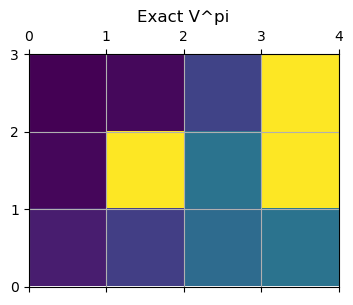

In [9]:
def vector_to_matrix(V_vec):
    return V_vec.reshape(state_matrix.shape)

V_exact = vector_to_matrix(V_vec)
print("Exact Value function:")
print(V_exact)

plt.matshow(V_exact, extent=[0, 4, 0, 3])
plt.title("Exact V^pi")
plt.grid()
plt.show()

## 4.3 Exercise 2

Another way to evaluate a policy is to iteratively apply the Bellman operator: $$V_{k+1}(s) = \sum_{s'} P(s'|s,\pi(s)) \left[ R(s') + \gamma V_k(s') \right]$$ This procedure converges to the true value of the policy because the Bellman operator is a contraction.

Iterative V:
[[-2.88491702 -2.82657248 -2.29963277  0.        ]
 [-2.83062702  0.         -1.78943839  0.        ]
 [-2.65821862 -2.35027684 -1.87569642 -1.79034615]]


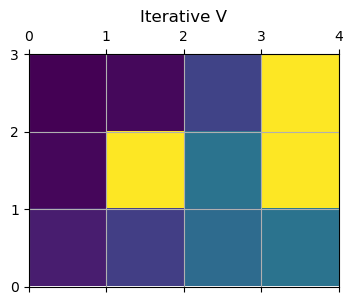

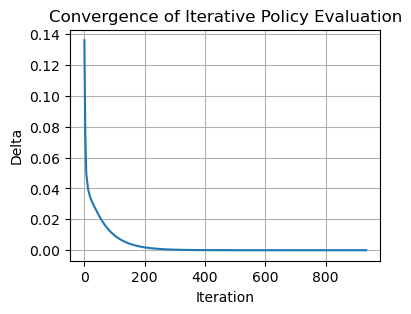

In [10]:
def iterative_policy_evaluation(policy_matrix, tol=1e-8, max_iter=10000):
    V = np.zeros(state_matrix.shape)
    errors = []

    for _ in range(max_iter):
        old_V = V.copy()
        delta = 0.0

        state = np.nditer(state_matrix, flags=['multi_index'])
        while not state.finished:
            s = state.multi_index

            if state_matrix[s] == 0:
                action = int(policy_matrix[s])
                value = 0.0
                next_states = prob_next_state(s)

                for ns, p in zip(next_states, transition_matrix[action]):
                    value += p * (reward_matrix[ns] + gamma * old_V[ns])

                V[s] = value
                delta = max(delta, abs(V[s] - old_V[s]))
            else:
                V[s] = 0.0

            state.iternext()

        errors.append(delta)
        if delta < tol:
            break

    return V, errors

V_iter, errors_iter = iterative_policy_evaluation(policy_matrix)

print("Iterative V:")
print(V_iter)

plt.matshow(V_iter, extent=[0, 4, 0, 3])
plt.title("Iterative V")
plt.grid()
plt.show()

plt.plot(errors_iter)
plt.xlabel("Iteration")
plt.ylabel("Delta")
plt.title("Convergence of Iterative Policy Evaluation")
plt.grid()
plt.show()



In [11]:
valid_mask = (state_matrix != -1)

print("Maximum difference between exact method and iterative method:")
print(np.max(np.abs(V_exact[valid_mask] - V_iter[valid_mask])))

Maximum difference between exact method and iterative method:
5.967550498198193e-07


## 4.4 Exercise 3

To experimentally verify that the Bellman operator is contractive, two different initial vectors, $V_0$ and $U_0$ are considered.

The operator is then applied iteratively, and the following quantity is plotted: $$\max_s |V_n(s) - U_n(s)|$$ If the operator is contractive, this distance must decrease with each iteration.

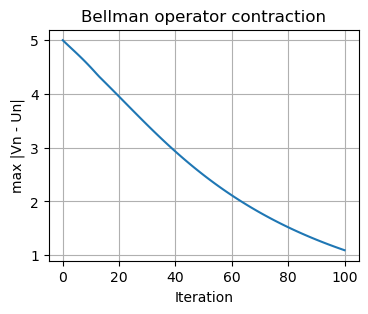

In [12]:
def one_policy_eval_step(V, policy_matrix):
    new_V = V.copy()

    state = np.nditer(state_matrix, flags=['multi_index'])
    while not state.finished:
        s = state.multi_index

        if state_matrix[s] == 0:
            action = int(policy_matrix[s])
            value = 0.0
            next_states = prob_next_state(s)

            for ns, p in zip(next_states, transition_matrix[action]):
                value += p * (reward_matrix[ns] + gamma * V[ns])

            new_V[s] = value
        else:
            new_V[s] = 0.0

        state.iternext()

    return new_V

Vn = np.zeros(state_matrix.shape)
Un = np.ones(state_matrix.shape) * 5.0

for pos in [(0, 3), (1, 3), (1, 1)]:
    Vn[pos] = 0.0
    Un[pos] = 0.0

diffs = [np.max(np.abs(Vn - Un))]

for _ in range(100):
    Vn = one_policy_eval_step(Vn, policy_matrix)
    Un = one_policy_eval_step(Un, policy_matrix)
    diffs.append(np.max(np.abs(Vn - Un)))

plt.plot(diffs)
plt.xlabel("Iteration")
plt.ylabel("max |Vn - Un|")
plt.title("Bellman operator contraction")
plt.grid()
plt.show()

# 5. Optimization

## 5.1 Theory Section

This section focuses on finding the optimal policy.

To achieve this, the Bellman optimality equation (which characterizes the optimal value function $V^*$) will be used.

Two classic algorithms will be applied:
+ **Value Iteration**, which directly updates the optimal vlaue function.
+ **Policy Iteration**, which alternates between policy evaluation and greedy improvement.

Finally, the given policy will be compared to the optimal policy, and we will study how the solution change as the discount factor $\gamma$ varies.

To solve the optimal control problem, the Bellman optimality equation is used:$$V^*(s)=\max_{a\in A}\sum_{s'} P(s'|s,a)\left[R(s')+\gamma V^*(s')\right]$$The Value Iteration algorithm iteratively applies this maximum operator until it converges to the optimal value function $V^*$. Once obtained, the optimal policy is recovered by choosing, for each state, the action that maximizes the expression above.

Policy Iteration alternates between two phases:
1. Policy Evaluation: Calculating $V^\pi$ for the current policy.
2. Policy Improvement: Constructing a new policy that is greedy with respect to $V^\pi$.

This process is repeated until the policy no longer changes. At that point, the optimal policy has been reached.

## 5.2 Exercise 1

The optimal value function $V^*$ satisfies:$$V^*(s) = \max_{a \in A} \sum_{s'} P(s'|s,a)\left[R(s') + \gamma V^*(s')\right]$$This equation characterizes the best expected cumulative reward that can be obtained from each state.

## 5.3 Exercise 2

[[0.76272886 0.84266749 0.92396705 0.        ]
 [0.68424217 0.         0.61687106 0.        ]
 [0.60799114 0.53968767 0.52011777 0.27985238]]


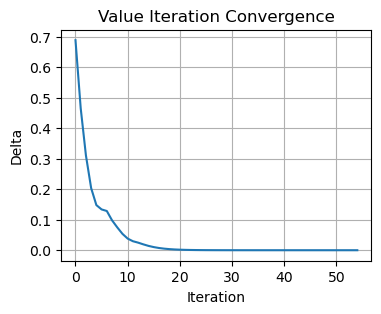

In [13]:
def value_iteration(tol=1e-8, max_iter=10000):
    V = np.zeros(state_matrix.shape)
    history = []

    for _ in range(max_iter):
        old_V = V.copy()
        delta = 0.0

        state = np.nditer(state_matrix, flags=['multi_index'])
        while not state.finished:
            s = state.multi_index

            if state_matrix[s] == 0:
                q_values = []

                for action in range(4):
                    q = 0.0
                    next_states = prob_next_state(s)

                    for ns, p in zip(next_states, transition_matrix[action]):
                        q += p * (reward_matrix[ns] + gamma * old_V[ns])

                    q_values.append(q)

                V[s] = max(q_values)
                delta = max(delta, abs(V[s] - old_V[s]))
            else:
                V[s] = 0.0

            state.iternext()

        history.append(delta)
        if delta < tol:
            break

    return V, history

V_star, vi_history = value_iteration()

print(V_star)

plt.plot(vi_history)
plt.xlabel("Iteration")
plt.ylabel("Delta")
plt.title("Value Iteration Convergence")
plt.grid()
plt.show()

## 5.4 Exercise 3

[[ 1.  1.  1. -1.]
 [ 0. nan  0. -1.]
 [ 0.  3.  0.  3.]]


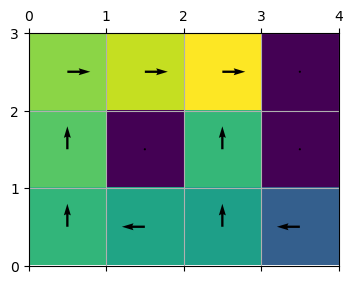

In [14]:
def greedy_policy_from_value(V):
    policy = np.full(state_matrix.shape, -1.0)

    state = np.nditer(state_matrix, flags=['multi_index'])
    while not state.finished:
        s = state.multi_index

        if state_matrix[s] == 0:
            q_values = []

            for action in range(4):
                q = 0.0
                next_states = prob_next_state(s)

                for ns, p in zip(next_states, transition_matrix[action]):
                    q += p * (reward_matrix[ns] + gamma * V[ns])

                q_values.append(q)

            policy[s] = np.argmax(q_values)

        elif state_matrix[s] == -1:
            policy[s] = np.nan
        else:
            policy[s] = -1

        state.iternext()

    return policy

optimal_policy = greedy_policy_from_value(V_star)
optimal_policy = optimal_policy.astype(float)

optimal_policy[state_matrix == 1] = -1
optimal_policy[state_matrix == -1] = np.nan

print(optimal_policy)
print_policy(optimal_policy, V_star)

## 5.5 Exercise 4

In [ ]:
V_given, _ = iterative_policy_evaluation(policy_matrix)

print("V for the given policy:")
print(V_given)

print("V for the optimal policy:")
print(V_star)

print("State-by-state improvement:")
print(V_star - V_given)

V política dada:
[[-2.88491702 -2.82657248 -2.29963277  0.        ]
 [-2.83062702  0.         -1.78943839  0.        ]
 [-2.65821862 -2.35027684 -1.87569642 -1.79034615]]
V política óptima:
[[0.76272886 0.84266749 0.92396705 0.        ]
 [0.68424217 0.         0.61687106 0.        ]
 [0.60799114 0.53968767 0.52011777 0.27985238]]
Mejora estado a estado:
[[3.64764588 3.66923997 3.22359982 0.        ]
 [3.51486919 0.         2.40630945 0.        ]
 [3.26620977 2.88996452 2.39581419 2.07019854]]


The optimal policy is considered superior because it produces a value function that is greater than or equal across all states, and strictly greater in at least some of them.

Therefore, the expected cumulative return when following the optimal policy exceeds that of the given policy.

## 5.6 Exercises 5 and 6

Convergencia en 4 iteraciones
[[ 1.  1.  1. -1.]
 [ 0. nan  0. -1.]
 [ 0.  3.  0.  3.]]


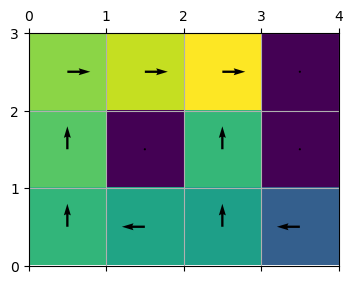

In [ ]:
def greedy_improvement(V):
    return greedy_policy_from_value(V)

def policy_iteration(initial_policy, tol=1e-8, max_iter=100):
    policy = initial_policy.copy()

    for it in range(max_iter):
        V, _ = iterative_policy_evaluation(policy, tol=tol)
        new_policy = greedy_improvement(V)

        stable = True
        state = np.nditer(state_matrix, flags=['multi_index'])
        while not state.finished:
            s = state.multi_index
            if state_matrix[s] == 0 and policy[s] != new_policy[s]:
                stable = False
                break
            state.iternext()

        policy = new_policy

        if stable:
            print(f"Convergence in {it+1} iterations")
            return policy, V

    return policy, V

policy_pi, V_pi = policy_iteration(policy_matrix)

print(policy_pi)
print_policy(policy_pi, V_pi)

## 5.7 Exercise 7


Gamma = 0.1
[[ 1.  1.  1. -1.]
 [ 0. nan  0. -1.]
 [ 0.  3.  3.  3.]]


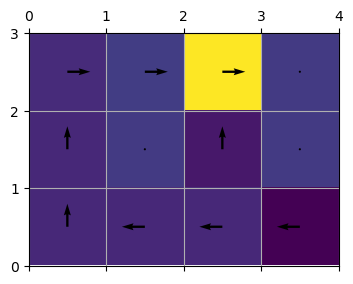


Gamma = 0.3
[[ 1.  1.  1. -1.]
 [ 0. nan  0. -1.]
 [ 0.  1.  0.  3.]]


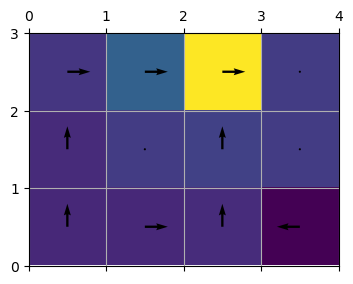


Gamma = 0.5
[[ 1.  1.  1. -1.]
 [ 0. nan  0. -1.]
 [ 0.  1.  0.  3.]]


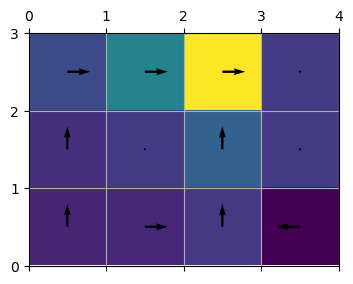


Gamma = 0.7
[[ 1.  1.  1. -1.]
 [ 0. nan  0. -1.]
 [ 0.  1.  0.  3.]]


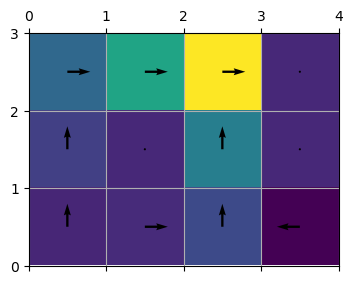


Gamma = 0.9
[[ 1.  1.  1. -1.]
 [ 0. nan  0. -1.]
 [ 0.  1.  0.  3.]]


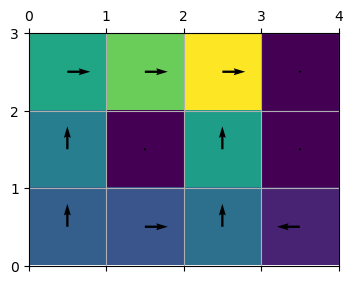


Gamma = 0.99
[[ 1.  1.  1. -1.]
 [ 0. nan  0. -1.]
 [ 0.  3.  0.  3.]]


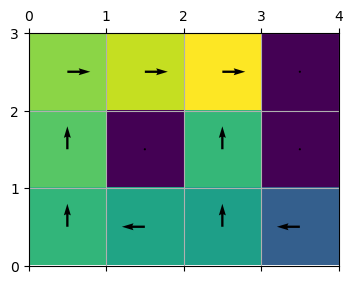

In [17]:
gammas = [0.1, 0.3, 0.5, 0.7, 0.9, 0.99]

for g in gammas:
    gamma = g
    Vg, _ = value_iteration()
    pig = greedy_policy_from_value(Vg)

    print(f"\nGamma = {g}")
    print(pig)
    print_policy(pig, Vg)

In [18]:
gamma = 0.99